In [1]:
import math
import os
import random
from collections import defaultdict
from itertools import product

import pandas as pd
import numpy as np

from sklearn import preprocessing
from sklearn.neighbors import KNeighborsClassifier
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
from dmba import plotDecisionTree, textDecisionTree

import seaborn as sns

import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

# K-Nearest Neighbors
## A Small Example: Predicting Loan Default

In [2]:
# Load loan data and disply the first 5 rows
loan200 = pd.read_csv('loan200.csv')
loan200.head()

,outcome,payment_inc_ratio,dti
0,target,9.00000,22.50
1,default,5.46933,21.33
2,paid off,6.90294,8.97
3,paid off,11.14800,1.83
4,default,3.72120,10.81


In [3]:
# Create the X and y datasets for the model
# Build a KNeighborsClassifier
# Predict the probability of a new loan defaulting

predictors = ["payment_inc_ratio", "dti"]
outcome = ["outcome"]

newloan = loan200.loc[0:0, predictors]
X = loan200.loc[1:,predictors]
y = loan200.loc[1:, outcome]

knn = KNeighborsClassifier(n_neighbors=20)
knn.fit(X,y)
knn.predict(newloan)
print(knn.predict_proba(newloan))

[[0.45 0.55]]


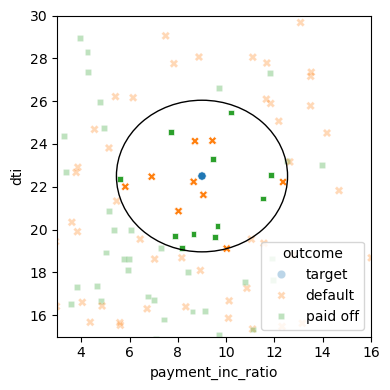

In [4]:
# PLot the KNN of the newloan
nbrs = knn.kneighbors(newloan)
maxDistance = np.max(nbrs[0][0])


fig, ax = plt.subplots(figsize=(4,4))

# Create scatterplot of all the loan data by payment_inc_ration and dti columns
sns.scatterplot(data=loan200,
                x = "payment_inc_ratio",
                y="dti",
                style="outcome",
                hue="outcome",
                alpha=0.3,
                ax=ax)

# Create a scatterplot of the KNN datapoints for the loan data
sns.scatterplot(data=pd.concat([loan200.loc[0:0,:],
                             loan200.loc[nbrs[1][0]+1,:]]), 
                x = "payment_inc_ratio",
                y = "dti",
                style="outcome",
                hue="outcome",
                ax=ax,
                legend=False)

# Create an ellipse are the KNN data points
# The blue dot in the middle is the new loan value
ellipse = Ellipse(xy=newloan.values[0], 
                  width=2 * maxDistance, height=2 * maxDistance,
                  edgecolor='black', fc='None', lw=1)
ax.add_patch(ellipse)
ax.set_xlim(3,16)
ax.set_ylim(15,30)

plt.tight_layout()
plt.show()



## Standardization (Normalization, Z-Scores)

In [5]:
# Load loan data and display first 5 rows
loan_data = pd.read_csv('loan_data.csv.gz')
loan_data.head()

,Unnamed: 0,status,loan_amnt,term,annual_inc,dti,payment_inc_ratio,revol_bal,revol_util,purpose,...,delinq_2yrs_zero,pub_rec_zero,open_acc,grade,outcome,emp_length,purpose_,home_,emp_len_,borrower_score
0,1,Charged Off,2500,60 months,30000,1.00,2.39320,1687,9.4,car,...,1,1,3,4.8,default,1,major_purchase,RENT,> 1 Year,0.65
1,2,Charged Off,5600,60 months,40000,5.55,4.57170,5210,32.6,small_business,...,1,1,11,1.4,default,5,small_business,OWN,> 1 Year,0.80
2,3,Charged Off,5375,60 months,15000,18.08,9.71600,9279,36.5,other,...,1,1,2,6.0,default,1,other,RENT,> 1 Year,0.60
3,4,Charged Off,9000,36 months,30000,10.08,12.21520,10452,91.7,debt_consolidation,...,1,1,4,4.2,default,1,debt_consolidation,RENT,> 1 Year,0.50
4,5,Charged Off,10000,36 months,100000,7.06,3.90888,11997,55.5,other,...,1,1,14,5.4,default,4,other,RENT,> 1 Year,0.55


In [6]:
# Drop the "Unnamed: 0" and "status" columns 
loan_data = loan_data.drop(columns=["Unnamed: 0","status"])

In [7]:
# Change the outcome column to a categorical type
loan_data["outcome"]=pd.Categorical(
    loan_data["outcome"],
    categories=["paid off", "default"],
    ordered=True)

In [8]:
# Establish the X and y field list for the model
predictors = ["payment_inc_ratio",
              "dti",
              "revol_bal",
              "revol_util"]
outcome = "outcome"

# Use the first record as the test predoctor row
newloan = loan_data.loc[0:0, predictors]
print(newloan)

# Establish the X and y datasets for the model
X = loan_data.loc[1:, predictors]
y = loan_data.loc[1:, outcome]

# Build the KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X,y)

# Find the nearest five neighbors to the test row (0)
nbrs = knn.kneighbors(newloan)
print(X.iloc[nbrs[1][0],:])

   payment_inc_ratio  dti  revol_bal  revol_util
0             2.3932  1.0       1687         9.4
       payment_inc_ratio   dti  revol_bal  revol_util
35536            1.47212  1.46       1686        10.0
33651            3.38178  6.37       1688         8.4
25863            2.36303  1.39       1691         3.5
42953            1.28160  7.14       1684         3.9
43599            4.12244  8.98       1684         7.2


In [9]:
# Use the first record as the test predoctor row
newloan = loan_data.loc[0:0, predictors]

# Establish the X and y datasets for the model
X = loan_data.loc[1:, predictors]
y = loan_data.loc[1:, outcome]

# Scale the X data. The value of 1.0 indicates the scale will not be adjusted
scaler = preprocessing.StandardScaler()
scaler.fit(X*1.0)

# Transform the X and newloan data to the scaled model
X_std = scaler.transform(X * 1.0)
newloan_std = scaler.transform(newloan*1.0)

# Build the KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_std, y)

# Find the nearest five neighbors to the scaled test row (0)
nbrs = knn.kneighbors(newloan_std)
print(X.iloc[nbrs[1][0], :])

       payment_inc_ratio   dti  revol_bal  revol_util
2080             2.61091  1.03       1218         9.7
1438             2.34343  0.51        278         9.9
30215            2.71200  1.34       1075         8.5
28542            2.39760  0.74       2917         7.4
44737            2.34309  1.37        488         7.2


## KNN as a Feature Engine

In [10]:
# Load the loan data
loan_data = pd.read_csv('loan_data.csv.gz')

# Drop the "Unnamed: 0" and "status" columns
loan_data = loan_data.drop(columns = ["Unnamed: 0",
                                      "status"])

# Change the outcome column to a categorical type
loan_data['outcome'] = pd.Categorical(loan_data['outcome'], 
                                      categories=['paid off', 'default'], 
                                      ordered=True)

# Establish the X and y field list for the model
predictors = ['dti', 'revol_bal', 'revol_util', 'open_acc', 
              'delinq_2yrs_zero', 'pub_rec_zero']
outcome = 'outcome'

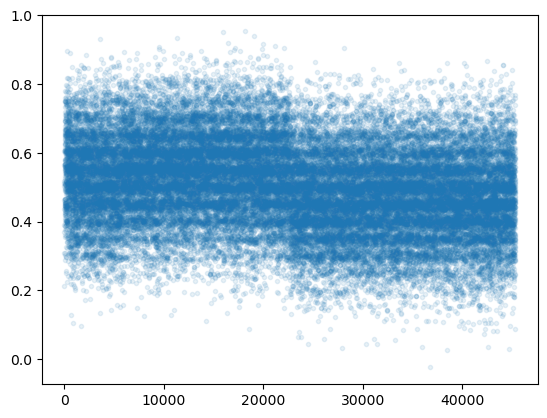

count    45342.000000
mean         0.499006
std          0.128687
min          0.050000
25%          0.400000
50%          0.500000
75%          0.600000
max          1.000000
Name: borrower_score, dtype: float64


In [11]:
# Establish the X and y datasets for the model
X = loan_data[predictors]
y = loan_data[outcome]

# Build the KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=20)
knn.fit(X,y)

# Plot the probability predictions in a scatterplot
plt.scatter(range(len(X)),
            [bs + random.gauss(0,0.015) for bs in knn.predict_proba(X)[:,0]],
            alpha=0.1,
            marker=".")
plt.show()

knn.predict_proba(X)[:,0]

loan_data["borrower score"] = knn.predict_proba(X)[:,0]
print(loan_data["borrower_score"].describe())

# Tree Models
## A Simple Example

In [12]:
# Load the loan data
loan3000 = pd.read_csv('loan3000.csv')

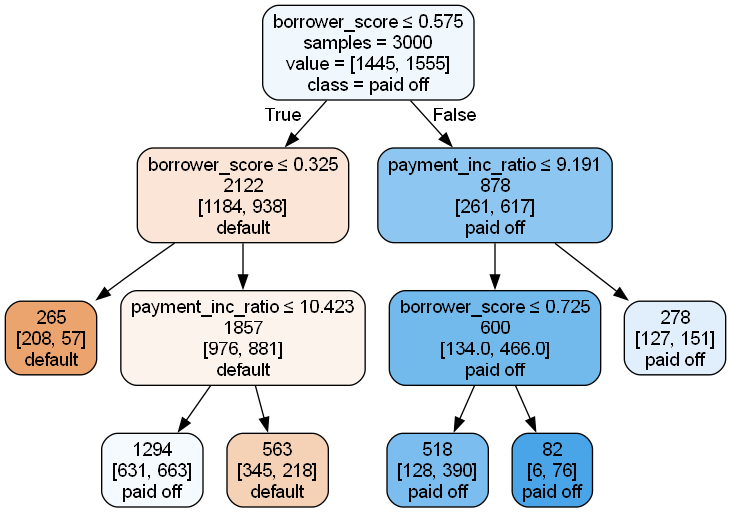

In [13]:
# Establish the X and y field list for the model
predictors = ["borrower_score","payment_inc_ratio"]
outcome = "outcome"

# Establish the X and y datasets for the model
X = loan3000[predictors]
y = loan3000[outcome]

# Build the decision tree model
loan_tree = DecisionTreeClassifier(random_state=1,
                                   criterion = 'entropy',
                                   min_impurity_decrease=0.003)
loan_tree.fit(X,y)

# Plot the decision tree model
plotDecisionTree(loan_tree,
                 feature_names=predictors,
                 class_names=loan_tree.classes_)

In [14]:
print(textDecisionTree(loan_tree))

node=0 test node: go to node 1 if 0 <= 0.5750000178813934 else to node 6
  node=1 test node: go to node 2 if 0 <= 0.32500000298023224 else to node 3
    node=2 leaf node: [[0.785, 0.215]]
    node=3 test node: go to node 4 if 1 <= 10.42264986038208 else to node 5
      node=4 leaf node: [[0.488, 0.512]]
      node=5 leaf node: [[0.613, 0.387]]
  node=6 test node: go to node 7 if 1 <= 9.19082498550415 else to node 10
    node=7 test node: go to node 8 if 0 <= 0.7249999940395355 else to node 9
      node=8 leaf node: [[0.247, 0.753]]
      node=9 leaf node: [[0.073, 0.927]]
    node=10 leaf node: [[0.457, 0.543]]


## The Recursive Partitioning Algorithm

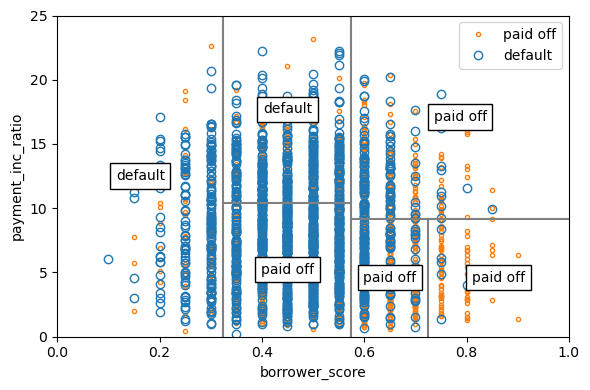

In [15]:
fig, ax = plt.subplots(figsize=(6,4))

# For paid off loans, plot the borrow_score and payment_ince_ration values
loan3000.loc[loan3000.outcome=="paid off"].plot(
    x="borrower_score",
    y="payment_inc_ratio",
    style=".",
    markerfacecolor="none",
    markeredgecolor="C1",
    ax=ax)

# For defaulted loans, plot the borrow_score and payment_ince_ration values
loan3000.loc[loan3000.outcome=="default"].plot(
    x="borrower_score",
    y="payment_inc_ratio",
    style="o",
    markerfacecolor="none",
    markeredgecolor="C0",
    ax=ax)
ax.legend(["paid off","default"])
ax.set_xlim(0,1)
ax.set_ylim(0,25)
ax.set_xlabel("borrower_score")
ax.set_ylabel("payment_inc_ratio")

# set the x and y plot points based on the decision tree test node values
x0 = 0.575 # This is test node 0 decision value of the decision tree
x1a = 0.325; y1b = 9.191 # x1a is the test node 1 decision value, y1b is the test node 6 value
y2a = 10.423; x2b = 0.725 # y2a is the test node 3 decision value, x2b is the test node 7 value

# Plot the test node 0 vertical line
ax.plot((x0, x0), (0, 25), color='grey')

# PLot the test node 1 vertical line
ax.plot((x1a, x1a), (0, 25), color='grey')

# PLot the test node 6 horizontal line
ax.plot((x0, 1), (y1b, y1b), color='grey')

# Plot the test node 1 and 3 horizontal line
ax.plot((x1a, x0), (y2a, y2a), color='grey')

# Plot the test node node 6 and 7 vertical line
ax.plot((x2b, x2b), (0, y1b), color='grey')

labels = [('default', (x1a / 2, 25 / 2)),
          ('default', ((x0 + x1a) / 2, (25 + y2a) / 2)),
          ('paid off', ((x0 + x1a) / 2, y2a / 2)),
          ('paid off', ((1 + x0) / 2, (y1b + 25) / 2)),
          ('paid off', ((1 + x2b) / 2, (y1b + 0) / 2)),
          ('paid off', ((x0 + x2b) / 2, (y1b + 0) / 2)),
          ]
for label, (x, y) in labels:
    ax.text(x, y, label, bbox={'facecolor':'white'},
            verticalalignment='center', horizontalalignment='center')

plt.tight_layout()
plt.show()

## Measuring Homogeneity or Impurity

In [16]:
# Create functions for entropy and gini impurity
def entropyFunction(x):
    if x == 0: return 0
    return -x * math.log(x, 2) - (1 - x) * math.log(1 - x, 2)

def giniFunction(x):
    return x * (1 - x)

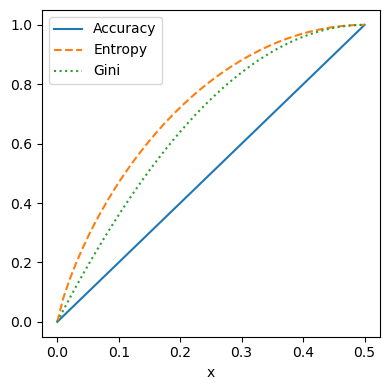

In [17]:
# Create manual data
x = np.linspace(0, 0.5, 50)

# Create a dataframe from a dictionary
impure = pd.DataFrame({
    "x":x,
    "Accuracy": 2 * x,
    "Gini": [giniFunction(xi) / giniFunction(0.5) for xi in x],
    "Entropy": [entropyFunction(xi) for xi in x]
})

fig, ax = plt.subplots(figsize=(4,4))

# Plot lines showing the accuracy, entropy and gini lines
impure.plot(x="x", y="Accuracy", ax=ax, linestyle="solid")
impure.plot(x="x", y="Entropy", ax=ax, linestyle="--")
impure.plot(x="x", y="Gini", ax=ax, linestyle=":")

plt.tight_layout()
plt.show()

# Bagging and the Random Forest
## Random Forest

In [18]:
# Establish the X and y field list for the model
predictors = ["borrower_score","payment_inc_ratio"]
outcome="outcome"

# Establish the X and y datasets for the model
X = loan3000[predictors]
y = loan3000[outcome]

# Create a RandomForestClassifier model and include the oob scores
rf = RandomForestClassifier(n_estimators=500,
                            random_state=1,
                            oob_score=True)
rf.fit(X,y)

# Print the out-of-bag (OOB): Error rate for the trained model applied to 
#     data left out of the training set for that tree
# Left value is the probability of classifying a '0'
# Right value is the probability of classifying a '1'
print(rf.oob_decision_function_)

[[0.18131868 0.81868132]
 [0.26704545 0.73295455]
 [0.93333333 0.06666667]
 ...
 [1.         0.        ]
 [0.73157895 0.26842105]
 [0.68085106 0.31914894]]


In [19]:
# Create a list of ranges from 20 to 505 by 5
n_estimator = list(range(20,510,5))

# Create an empty oobScores list
oobScores = []

# For each estimator, create a RandomForestClassifier
# Append the oob_score_ values to the oobScores list
for n in n_estimator:
    rf = RandomForestClassifier(n_estimators=n,
                                 criterion="entropy",
                                 max_depth=5,
                                 random_state=1,
                                 oob_score=True)
    rf.fit(X,y)
    oobScores.append(rf.oob_score_)

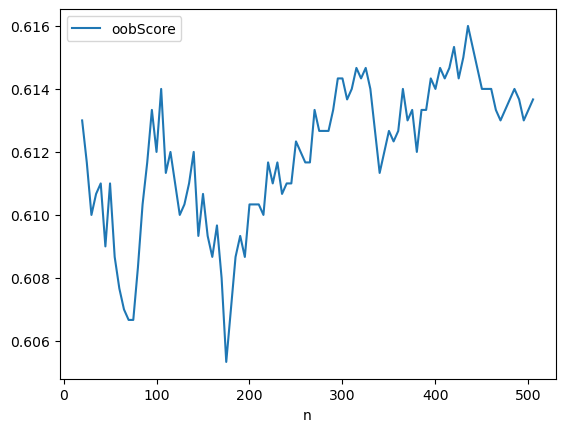

In [20]:
# Create a dataframe of the estimator and related oobScores
# Plot the scores: : X= estimator y=oobScores
pd.DataFrame({
    'n': n_estimator, 
    'oobScore': oobScores
}).plot(x='n', y='oobScore')
plt.show()

   borrower_score  payment_inc_ratio prediction
0            0.40            5.11135    default
1            0.40            5.43165    default
2            0.70            9.23003   paid off
3            0.40            2.33482   paid off
4            0.45           12.10320    default


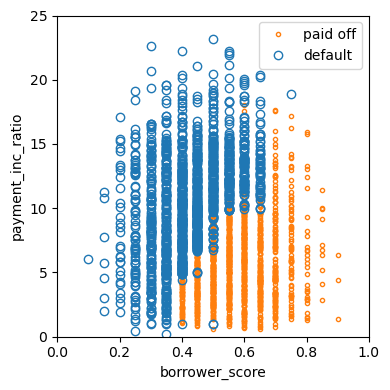

In [21]:

# Make a copy of the X dataframe
predictions = X.copy()

# Predict the target value based on X and save the result in the 'prediction' column
predictions['prediction'] = rf.predict(X)

# Display the first 5 rows of the predictions
print(predictions.head())

fig, ax = plt.subplots(figsize=(4,4))

# PLot the paid off predictions by the x and y data pts
# These get a small orange circle
predictions.loc[predictions.prediction=="paid off"].plot(
    x="borrower_score",
    y="payment_inc_ratio",
    style=".",
    markerfacecolor="none",
    markeredgecolor="C1",
    ax=ax)

# PLot the default predictions by the x and y data pts
# These get a small blue circle
predictions.loc[predictions.prediction=="default"].plot(
    x="borrower_score",
    y="payment_inc_ratio",
    style="o",
    markerfacecolor="none",
    markeredgecolor="C0",
    ax=ax)
ax.legend(["paid off", "default"]);
ax.set_xlim(0,1)
ax.set_ylim(0,25)
ax.set_xlabel("borrower_score")
ax.set_ylabel("payment_inc_ratio")

plt.tight_layout()
plt.show()

## Variable importance
This is different to R. The accuracy decrease is not available out of the box.

In [22]:
# Create a RandomForestClassifier based on multiple variables
predictors = ['loan_amnt', 'term', 'annual_inc', 'dti', 
              'payment_inc_ratio', 'revol_bal', 'revol_util', 
              'purpose', 'delinq_2yrs_zero', 'pub_rec_zero', 
              'open_acc', 'grade', 'emp_length', 'purpose_', 
              'home_', 'emp_len_', 'borrower_score']
outcome = 'outcome'

X = pd.get_dummies(loan_data[predictors], drop_first=True, dtype=int)
y = loan_data[outcome]

rf_all = RandomForestClassifier(n_estimators=500, random_state=1)
rf_all.fit(X, y)

rf_all_entropy = RandomForestClassifier(n_estimators=500, random_state=1,
                                        criterion='entropy')
print(rf_all_entropy.fit(X, y))

RandomForestClassifier(criterion='entropy', n_estimators=500, random_state=1)


In [23]:
rf = RandomForestClassifier(n_estimators=500)
scores = defaultdict(list)
 
# Cross validate the scores on a number of different random splits of the data
for _ in range(3):
    train_X, valid_X, train_y, valid_y = train_test_split(X, y, 
                                                          test_size=0.3)
    rf.fit(train_X, train_y)
    acc = metrics.accuracy_score(valid_y, rf.predict(valid_X))
    for column in X.columns:
        X_t = valid_X.copy()
        X_t[column] = np.random.permutation(X_t[column].values)
        shuff_acc = metrics.accuracy_score(valid_y, rf.predict(X_t))
        scores[column].append((acc-shuff_acc)/acc)

# PRint the feature importances
print('Features sorted by their score:')
print(sorted([(round(np.mean(score), 4), feat) for
              feat, score in scores.items()], reverse=True))

Features sorted by their score:
[(0.0772, 'borrower_score'), (0.0397, 'grade'), (0.0268, 'term_60 months'), (0.0134, 'payment_inc_ratio'), (0.0125, 'annual_inc'), (0.005, 'open_acc'), (0.0037, 'revol_bal'), (0.0037, 'dti'), (0.0033, 'revol_util'), (0.0033, 'emp_length'), (0.003, 'purpose__small_business'), (0.0024, 'purpose_small_business'), (0.0016, 'purpose_other'), (0.0013, 'pub_rec_zero'), (0.0013, 'home__RENT'), (0.0008, 'purpose__other'), (0.0008, 'loan_amnt'), (0.0006, 'delinq_2yrs_zero'), (0.0004, 'purpose_debt_consolidation'), (0.0004, 'emp_len__ > 1 Year'), (0.0002, 'purpose_medical'), (0.0002, 'purpose_home_improvement'), (0.0001, 'purpose_vacation'), (0.0001, 'purpose_house'), (0.0, 'purpose__medical'), (0.0, 'home__OWN'), (-0.0001, 'purpose_wedding'), (-0.0001, 'purpose__home_improvement'), (-0.0002, 'purpose_major_purchase'), (-0.0003, 'purpose_moving'), (-0.0004, 'purpose_credit_card'), (-0.0009, 'purpose__major_purchase'), (-0.0014, 'purpose__debt_consolidation')]


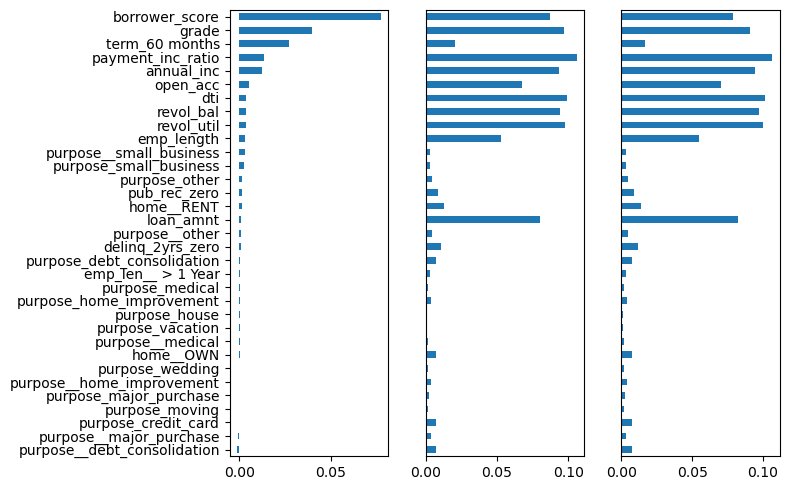

In [24]:
# PLot the features importances of the 3 models
#    Accuracy decrease
#    Gini decrease
#    Entropy decrease
importances = rf_all.feature_importances_

df = pd.DataFrame({
        "feature": X.columns,
        "Accuracy decrease": [np.mean(scores[column]) for column in
                              X.columns],
        "Gini decrease": rf_all.feature_importances_,
        "Entropy decrease": rf_all_entropy.feature_importances_    
})

df = df.sort_values("Accuracy decrease")

fig, axes = plt.subplots(ncols=3, figsize=(8,5))
ax = df.plot(kind="barh",
             x = "feature",
             y = "Accuracy decrease",
             legend=False,
             ax=axes[0])
ax.set_ylabel("")
ax = df.plot(kind="barh",
             x = "feature",
             y = "Gini decrease",
             legend=False,
             ax=axes[1])
ax.set_ylabel("")
ax.get_yaxis().set_visible(False)

ax = df.plot(kind="barh",
             x = "feature",
             y = "Entropy decrease",
             legend=False,
             ax=axes[2])
ax.set_ylabel("")
ax.get_yaxis().set_visible(False)

plt.tight_layout()
plt.show()

# Boosting
## XGBoost

In [25]:
# Establish the X and y field list for the model
predictors = ['borrower_score', 'payment_inc_ratio']
outcome = 'outcome'

# Establish the X and y datasets for the model
X = loan3000[predictors]
y = pd.Series([1 if o == 'default' else 0 for o in loan3000[outcome]])

# Build a logistic regression model using the XGBClassifier
xgb = XGBClassifier(objective="binary:logistic",
                    subsample=0.63,
                    use_label_encoder=False,
                    eval_metrics="error")
print(xgb.fit(X,y))

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, eval_metrics='error',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None, ...)


In [26]:
# Create a copy of the X predictor values
xgb_df = X.copy()

# Add a column for the prediction result
xgb_df["prediction"]=["default" if p==1 else "paid off" for p in xgb.predict(X)]

# Add a column for the predicted probability value
xgb_df["prob_default"] = xgb.predict_proba(X)[:,0]
print(xgb_df.head())

   borrower_score  payment_inc_ratio prediction  prob_default
0            0.40            5.11135   paid off      0.837470
1            0.40            5.43165    default      0.258429
2            0.70            9.23003    default      0.218399
3            0.40            2.33482   paid off      0.869448
4            0.45           12.10320    default      0.071927


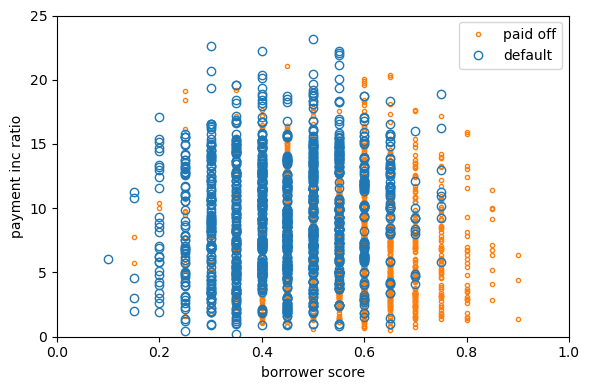

In [27]:
fig, ax = plt.subplots(figsize=(6,4))

# PLot the paid off predictions by the x and y data pts
# These get a small orange circle
xgb_df.loc[xgb_df.prediction=="paid off"].plot(
    x="borrower_score",
    y="payment_inc_ratio",
    style=".",
    markerfacecolor="none",
    markeredgecolor="C1",
    ax=ax)

# PLot the default predictions by the x and y data pts
# These get a small blue circle
xgb_df.loc[xgb_df.prediction=="default"].plot(
    x="borrower_score",
    y="payment_inc_ratio",
    style="o",
    markerfacecolor="none",
    markeredgecolor="C0",
    ax=ax)
ax.legend(["paid off","default"])
ax.set_ylim(0,25)
ax.set_xlim(0,1)
ax.set_xlabel("borrower score")
ax.set_ylabel("payment inc ratio")
plt.tight_layout()
plt.show()

## Regularization: Avoiding Overfitting

In [28]:
# Establish the X and y field list for the model
predictors = ['loan_amnt', 'term', 'annual_inc', 'dti', 
              'payment_inc_ratio', 'revol_bal', 'revol_util', 
              'purpose', 'delinq_2yrs_zero', 'pub_rec_zero', 
              'open_acc', 'grade', 'emp_length', 'purpose_', 
              'home_', 'emp_len_', 'borrower_score']
outcome = 'outcome'

# Establish the X and y datasets for the model
X = pd.get_dummies(loan_data[predictors],drop_first=True, dtype=int)
y = pd.Series([1 if o == 'default' else 0 for o in loan_data[outcome]])

# Split the data between training and validation sets
train_X, valid_X, train_y, valid_y = train_test_split(X, y, test_size = 10000)

# Build a logistic regression XGBClassifier model with no penalty
xgb_default = XGBClassifier(
    objective="binary:logistic",
    n_estimators=250,
    max_depth=6,
    reg_lambda=0, 
    learning_rate=0.3,
    subsample=1,
    use_label_encoder=False,
    eval_metrics="error")
xgb_default.fit(train_X, train_y)

# Reg_lambda is also known as squared Euclidean distance or L2-regularization
# also known as Ridge regression

# Reg_alpha is also known as Manhattan distance or L1-regularization
# also known as Lasso

# Regularization modifies the cost function in order to penalize the
# complexity of the model
# Increasing these parameters will penalize more complex models and
# Reduce the size of the trees that are fit

# Build a logistic regression XGBClassifier model with a penalty
xgb_penalty = XGBClassifier(
    objective='binary:logistic', 
    n_estimators=250, 
    max_depth=6,
    reg_lambda=1000, 
    learning_rate=0.1, 
    subsample=0.63,
    use_label_encoder=False, 
    eval_metric='error')
print(xgb_penalty.fit(train_X, train_y))



XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='error', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=250,
              n_jobs=None, num_parallel_tree=None, ...)


In [29]:
# Get the error rate for the default training set
pred_default = xgb_default.predict_proba(train_X)[:, 1]
error_default = abs(train_y - pred_default) > 0.5
print('default (train): ', np.mean(error_default))

# Get the error rate for the default testing set
pred_default = xgb_default.predict_proba(valid_X)[:, 1]
error_default = abs(valid_y - pred_default) > 0.5
print('default: ', np.mean(error_default))

# Get the error rate for the regularized testing set
pred_penalty = xgb_penalty.predict_proba(valid_X)[:, 1]
error_penalty = abs(valid_y - pred_penalty) > 0.5
print('penalty: ', np.mean(error_penalty))

default (train):  0.09886254314979345
default:  0.3555
penalty:  0.3332


##### Observations:
 - The default training set has an error rate of 10.6%
 - The default testing set, however, has an error rate of 35.8%
 - The regularized testing set has an error rate of 32.4%

In [30]:
# Build prediction results while changing the ntree_limit values
# Build models for the default train, default test, penalty train,  penalty test
results = []
for ntree_limit in range(1, 250):
    iteration_range = [1, ntree_limit + 1]
    train_default = xgb_default.predict_proba(train_X, iteration_range=iteration_range)[:, 1]
    train_penalty = xgb_penalty.predict_proba(train_X, iteration_range=iteration_range)[:, 1]
    pred_default = xgb_default.predict_proba(valid_X, iteration_range=iteration_range)[:, 1]
    pred_penalty = xgb_penalty.predict_proba(valid_X, iteration_range=iteration_range)[:, 1]
    results.append({
        'iterations': ntree_limit,
        'default train': np.mean(abs(train_y - train_default) > 0.5),
        'penalty train': np.mean(abs(train_y - train_penalty) > 0.5),
        'default test': np.mean(abs(valid_y - pred_default) > 0.5),
        'penalty test': np.mean(abs(valid_y - pred_penalty) > 0.5),
    })

results = pd.DataFrame(results)
print(results.head())

   iterations  default train  penalty train  default test  penalty test
0           1       0.340303       0.355413        0.3582        0.3599
1           2       0.331107       0.344604        0.3479        0.3546
2           3       0.323949       0.342539        0.3429        0.3526
3           4       0.319874       0.340643        0.3438        0.3546
4           5       0.316903       0.339002        0.3411        0.3517


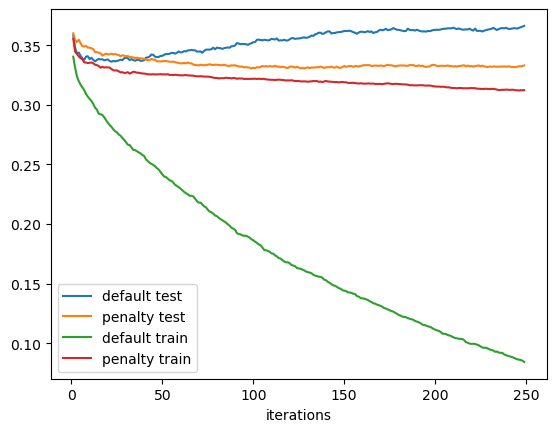

In [31]:
# Plot the error results of the 4 versions
ax = results.plot(x="iterations", y="default test")
results.plot(x='iterations', y="penalty test", ax=ax)
results.plot(x="iterations", y="default train", ax=ax)
results.plot(x="iterations", y="penalty train", ax=ax)
plt.show()
        

##### Observation: As the number of ntree_limit increase, overfitting tends to increase

## Hyperparameters and Cross-Validation

In [32]:
import warnings
warnings.filterwarnings("ignore")

In [33]:
# Build a cross validation model of a logistic regression using XGBClassifier
idx = np.random.choice(range(5), size=len(X), replace=True)
error=[]

for eta, max_depth in product([0.1, 0.5, 0.9], [3,6,9]):
    xgb = XGBClassifier(objective="binary:logistic",
                        n_estimators=250,
                        max_depth=max_depth,
                        learning_rate=eta,
                        eval_metrics="error")
    cv_error=[]
    for k in range(5):
        fold_idx = idx == k
        train_X = X.loc[~fold_idx]; train_y = y[~fold_idx]
        valid_X = X.loc[fold_idx]; valid_y = y[fold_idx]
        
        xgb.fit(train_X, train_y)
        pred = xgb.predict_proba(valid_X)[:,1]
        cv_error.append(np.mean(abs(valid_y-pred)>0.5))
    error.append({
        "eta": eta,
        "max_depth": max_depth,
        "avg_error": np.mean(cv_error)
    })
    print(error[-1])
errors = pd.DataFrame(error)
print(errors)

{'eta': 0.1, 'max_depth': 3, 'avg_error': 0.32673672811867555}
{'eta': 0.1, 'max_depth': 6, 'avg_error': 0.33566315509017114}
{'eta': 0.1, 'max_depth': 9, 'avg_error': 0.34476034424202134}
{'eta': 0.5, 'max_depth': 3, 'avg_error': 0.3396719069370091}
{'eta': 0.5, 'max_depth': 6, 'avg_error': 0.37028253075483797}
{'eta': 0.5, 'max_depth': 9, 'avg_error': 0.37050594138307436}
{'eta': 0.9, 'max_depth': 3, 'avg_error': 0.35140940337923665}
{'eta': 0.9, 'max_depth': 6, 'avg_error': 0.3850012808381164}
{'eta': 0.9, 'max_depth': 9, 'avg_error': 0.38389230584662454}
   eta  max_depth  avg_error
0  0.1          3   0.326737
1  0.1          6   0.335663
2  0.1          9   0.344760
3  0.5          3   0.339672
4  0.5          6   0.370283
5  0.5          9   0.370506
6  0.9          3   0.351409
7  0.9          6   0.385001
8  0.9          9   0.383892


##### Obervation: Model had a lower error rate when the eta was 0.1 and max_depth was 3

In [34]:
print(errors.pivot_table(index="eta", 
                         columns="max_depth",
                         values="avg_error") * 100)

max_depth          3          6          9
eta                                       
0.1        32.673673  33.566316  34.476034
0.5        33.967191  37.028253  37.050594
0.9        35.140940  38.500128  38.389231
